# 01 — Explorative Datenanalyse

## Business Problem

Ungeplante Stillstände von Industriemaschinen können für Unternehmen teuer sein. 
Die Produktion steht, es entstehen Folgeschäden an der Anlage, Liefertermine werden nicht eingehalten. 
Die Gegenmaßnahme, wie vorsorglich und in kurzen Abständen durchgeführte Wartund, verursacht aber
ihrerseits Kosten: Arbeitszeit, Ersatzteile und Produktionsunterbrechungen für Eingriffe, die gar nicht nötig gewesen wären.

Gesucht ist deshalb der Mittelweg. Gewartet werden soll dann, wenn es der
Zustand der Maschine verlangt, und nicht nach starrem Zeitplan. Dafür müssen
zwei Fragen beantwortbar sein:

* Unter welchen Betriebsbedingungen fällt eine Maschine aus?
* Lässt sich ein bevorstehender Ausfall früh genug an den Sensorwerten erkennen,
  um die Wartung noch zu planen?

Beide Fehler kosten unterschiedlich viel. Ein übersehener Ausfall ist um ein
Vielfaches teurer als ein Fehlalarm — dieses Verhältnis bestimmt später die Wahl
der Bewertungsmetrik und des Entscheidungsschwellenwerts.


In dem Notebook wird kein Modell gebaut und nichts trainiert. Dieses Notebook dient
ausschließlich dazu, die Rohdaten zu verstehen, bevor die erste Entscheidung
über Merkmale, Aufteilung oder Modellwahl fällt. Es wird geprüft:

* ob die Daten halten, was der Datenvertrag zusagt, 
  die Liste der Zusagen über Spalten, Typen und Wertebereiche,
* wie stark die Klassen unausgeglichen sind und was daraus für die Metrik folgt,
* welche Größen Ausfälle überhaupt von Normalbetrieb unterscheiden,
* welche Spalten Informationen enthalten, die zum Vorhersagezeitpunkt noch gar
  nicht vorliegen und deshalb entfernt werden müssen,
* ob die Daten zeilenweise aufgeteilt werden dürfen.


In [1]:
import numpy as np
import pandas as pd

from src.data.load import LEAKAGE_COLUMNS, TARGET_COLUMN, load_raw_data
from src.data.validate import load_params, validate_dataframe
from src.utils.plotting import (
    CMAP_KORRELATION,
    FARBEN,
    KLASSEN,
    nur_x_gitter,
    nur_y_gitter,
    setze_stil,
    speichere,
)

import matplotlib.pyplot as plt

setze_stil()
params = load_params()

# Die Rohdaten werden über load_raw_data() geladen: dort wird der Hash geprüft.
df = load_raw_data()
df.shape

(10000, 14)

## 1 Datenvertrag

In [2]:
ergebnis = validate_dataframe(df)
print(ergebnis.report())

37 Prüfungen ausgeführt.
Keine Beanstandungen — der Datenvertrag ist eingehalten.


Der Vertrag ist ohne Beanstandung eingehalten — die Daten sind vollständig, alle
Werte liegen im physikalisch plausiblen Bereich und es treten keine unbekannten
Kategorien auf.

## 2 Data Type checks

In [3]:
uebersicht = pd.DataFrame({
    "Typ": df.dtypes.astype(str),
    "fehlend": df.isna().sum(),
    "eindeutige Werte": df.nunique(),
})
print(f"{df.shape[0]} Zeilen x {df.shape[1]} Spalten")
uebersicht

10000 Zeilen x 14 Spalten


,Typ,fehlend,eindeutige Werte
udi,int64,0,10000
product_id,str,0,10000
type,str,0,3
air_temperature_k,float64,0,93
process_temperature_k,float64,0,82
rotational_speed_rpm,int64,0,941
torque_nm,float64,0,577
tool_wear_min,int64,0,246
machine_failure,int64,0,2
twf,int64,0,2


In [4]:
merkmale_numerisch = [
    "air_temperature_k",
    "process_temperature_k",
    "rotational_speed_rpm",
    "torque_nm",
    "tool_wear_min",
]
df[merkmale_numerisch].describe().T.round(2)

,count,mean,std,min,25%,50%,75%,max
air_temperature_k,10000.0,300.00,2.00,295.3,298.3,300.1,301.5,304.5
process_temperature_k,10000.0,310.01,1.48,305.7,308.8,310.1,311.1,313.8
rotational_speed_rpm,10000.0,1538.78,179.28,1168.0,1423.0,1503.0,1612.0,2886.0
torque_nm,10000.0,39.99,9.97,3.8,33.2,40.1,46.8,76.6
tool_wear_min,10000.0,107.95,63.65,0.0,53.0,108.0,162.0,253.0


Der Datensatz ist vollständig — keine fehlenden Werte in keiner Spalte — und die
fünf Prozessgrößen liegen in engen, physikalisch plausiblen Bereichen; eine
Bereinigung ist also nicht nötig, und der Aufwand kann in die Modellierung fließen.

## 3 Klassenverhältnis

### Target-Variable

Als Zielvariable wird `machine_failure` verwendet. Sie gibt binär an, ob die Maschine im jeweiligen Betriebszustand ausgefallen ist. 
**1** steht für einen Ausfall
**0** kennzeichnet einen normalen Betriebszustand 

Für die Interpretation der Zielvariable sind drei Einschränkungen besonders wichtig:

* **Keine Restlaufzeit:** Die Variable gibt nicht an, wann ein Ausfall eintreten wird, sondern lediglich, ob im betrachteten Betriebszustand ein Ausfall vorliegt. Eine Aussage wie „Die Maschine wird in 48 Stunden ausfallen“ lässt sich aus diesen Daten daher nicht ableiten.

* **Kein Schweregrad:** Unterschiedliche Fehlerarten werden gleichermaßen mit dem Wert 1 gekennzeichnet. Ein Lagerschaden wird somit genauso erfasst wie beispielsweise ein verschlissenes Werkzeug. Für die Kostenbetrachtung werden deshalb Durchschnittswerte verwendet.

* **Keine Zeitreihe:** Die Daten enthalten weder Zeitstempel noch eine zeitliche Reihenfolge der Beobachtungen. Jede Zeile wird daher unabhängig betrachtet. Das Modell bewertet somit einen einzelnen Betriebszustand und keinen zeitlichen Verlauf.

Das Modell beantwortet folglich die Frage, **ob ein bestimmter Betriebszustand kritisch ist**, und nicht, **wie lange die Maschine noch betrieben werden kann**. Für die Wartungsplanung liefert es damit ein Frühwarnsignal, aber keine konkrete Vorhersage des Ausfallzeitpunkts. Diese Einschränkung ist bei der Interpretation der Ergebnisse zu berücksichtigen.

Die Häufigkeit von Ausfällen im Datensatz hat zudem einen wesentlichen Einfluss auf die weitere Modellierung und Bewertung des Modells.


In [5]:
anzahl = df[TARGET_COLUMN].value_counts().sort_index()
anteil = df[TARGET_COLUMN].value_counts(normalize=True).sort_index()
positiv_anteil = float(anteil.loc[1])

print(f"kein Ausfall : {anzahl.loc[0]:>5d}  ({anteil.loc[0]:.2%})")
print(f"Ausfall      : {anzahl.loc[1]:>5d}  ({anteil.loc[1]:.2%})")
print(f"\nAccuracy der Vorhersage 'fällt nie aus': {anteil.loc[0]:.2%}")

kein Ausfall :  9661  (96.61%)
Ausfall      :   339  (3.39%)

Accuracy der Vorhersage 'fällt nie aus': 96.61%


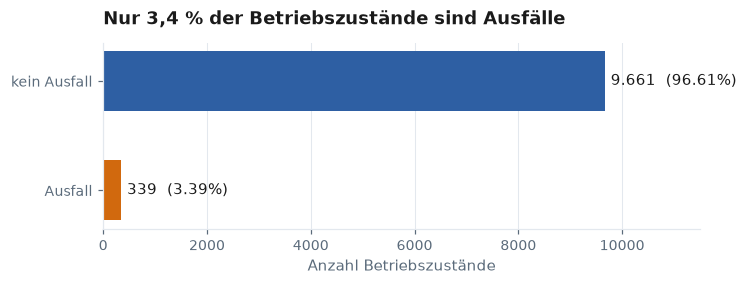

In [6]:
fig, ax = plt.subplots(figsize=(7, 2.2))

positionen = [0, 1]
werte = [anzahl.loc[0], anzahl.loc[1]]
farben = [FARBEN["kein_ausfall"], FARBEN["ausfall"]]

balken = ax.barh(positionen, werte, height=0.55, color=farben)

# Direkte Beschriftung statt Legende: eine Reihe, zwei Kategorien.
for pos, wert, anteil_wert in zip(positionen, werte, [anteil.loc[0], anteil.loc[1]]):
    ax.text(wert + 120, pos, f"{wert:,}".replace(",", ".") + f"  ({anteil_wert:.2%})",
            va="center", ha="left", fontsize=9.5, color=FARBEN["text"])

ax.set_yticks(positionen, [KLASSEN[0], KLASSEN[1]])
ax.set_xlim(0, 11500)
ax.set_xlabel("Anzahl Betriebszustände")
ax.set_title("Nur 3,4 % der Betriebszustände sind Ausfälle", loc="left")
nur_x_gitter(ax)
ax.invert_yaxis()

speichere(fig, "01_klassenverhaeltnis")
plt.show()

Nur 339 von 10.000 Betriebszuständen sind Ausfälle (3,39 %), weshalb **Accuracy als
Metrik ausscheidet**: die Vorhersage „fällt nie aus" erreicht damit 96,61 % und ist
trotzdem wertlos — bewertet wird stattdessen über PR-AUC und die erwarteten Kosten.

## 4 Verteilungen der Prozessgrößen nach Zielklasse

Weil die Klassen so ungleich besetzt sind, werden die Häufigkeiten je Klasse auf
1 normiert — sonst wäre die Ausfallklasse im Diagramm unsichtbar.

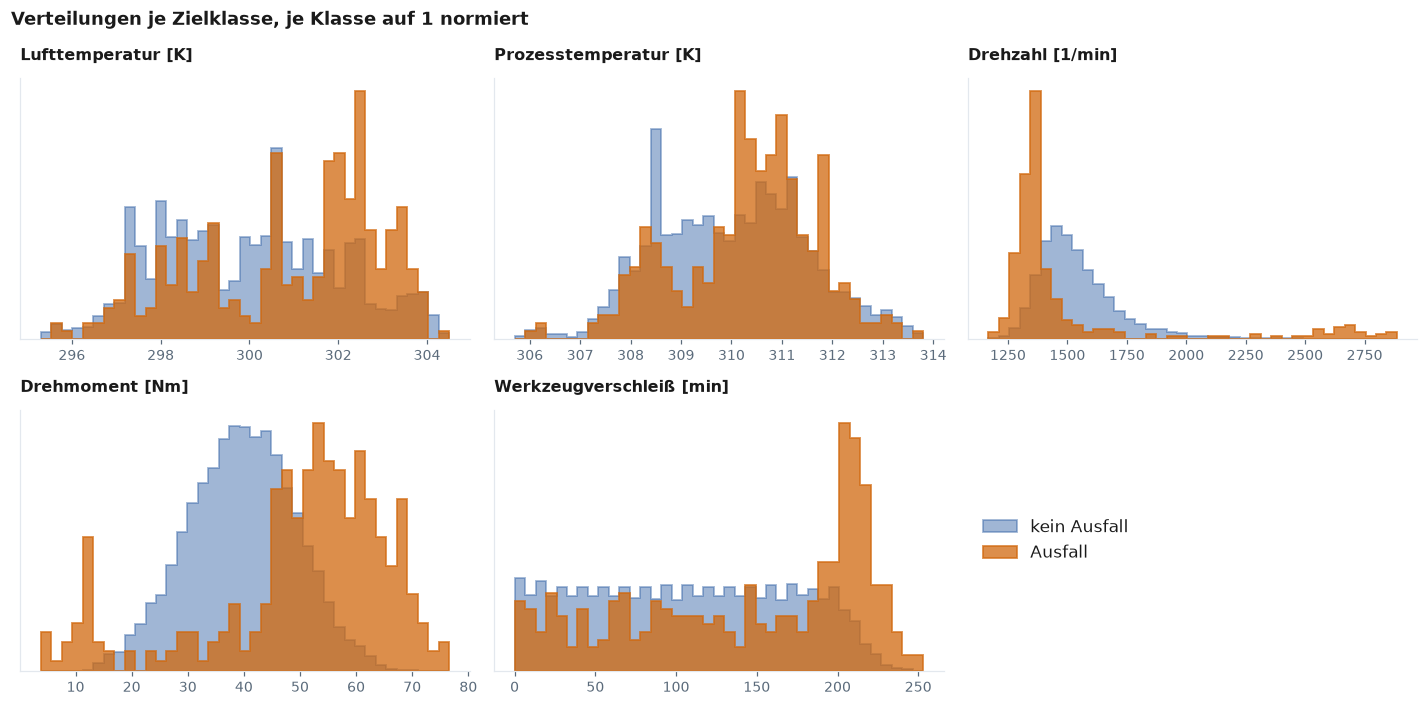

In [7]:
fig, achsen = plt.subplots(2, 3, figsize=(13, 6.5))
achsen = achsen.ravel()

beschriftung = {
    "air_temperature_k": "Lufttemperatur [K]",
    "process_temperature_k": "Prozesstemperatur [K]",
    "rotational_speed_rpm": "Drehzahl [1/min]",
    "torque_nm": "Drehmoment [Nm]",
    "tool_wear_min": "Werkzeugverschleiß [min]",
}

for ax, spalte in zip(achsen, merkmale_numerisch):
    grenzen = np.linspace(df[spalte].min(), df[spalte].max(), 40)
    for klasse, farbe in [(0, FARBEN["kein_ausfall"]), (1, FARBEN["ausfall"])]:
        ax.hist(
            df.loc[df[TARGET_COLUMN] == klasse, spalte],
            bins=grenzen, density=True, histtype="stepfilled",
            color=farbe, alpha=0.45 if klasse == 0 else 0.75,
            edgecolor=farbe, linewidth=1.2, label=KLASSEN[klasse],
        )
    ax.set_title(beschriftung[spalte], loc="left", fontsize=10.5)
    ax.set_yticks([])
    nur_y_gitter(ax)
    ax.grid(False)

achsen[-1].axis("off")
# Legende in das freie sechste Feld statt über die Balken.
griffe, namen = achsen[0].get_legend_handles_labels()
achsen[-1].legend(griffe, namen, loc="center left", fontsize=11)

fig.suptitle("Verteilungen je Zielklasse, je Klasse auf 1 normiert",
             x=0.005, ha="left", fontsize=12, fontweight="bold")
fig.tight_layout()

speichere(fig, "02_verteilungen_nach_klasse")
plt.show()

Am deutlichsten trennen **Drehmoment** und **Werkzeugverschleiß** — Ausfälle liegen
bei hoher Last und bei Verschleiß oberhalb von rund 200 Minuten —, während die
Drehzahl Ausfälle an *beiden* Rändern zeigt und die Temperaturen sich nur leicht
nach oben verschieben; keine Einzelgröße trennt also sauber, entscheidend ist ihr
Zusammenspiel (Abschnitt 8).

## 5 Qualitätsvariante und Ausfallrate

In [8]:
je_typ = (
    df.groupby("type")[TARGET_COLUMN]
    .agg([("anzahl", "size"), ("ausfälle", "sum")])
    .reindex(["L", "M", "H"])
)
je_typ["ausfallrate"] = je_typ["ausfälle"] / je_typ["anzahl"]
je_typ

,anzahl,ausfälle,ausfallrate
type,,,
L,6000,235,0.039167
M,2997,83,0.027694
H,1003,21,0.020937


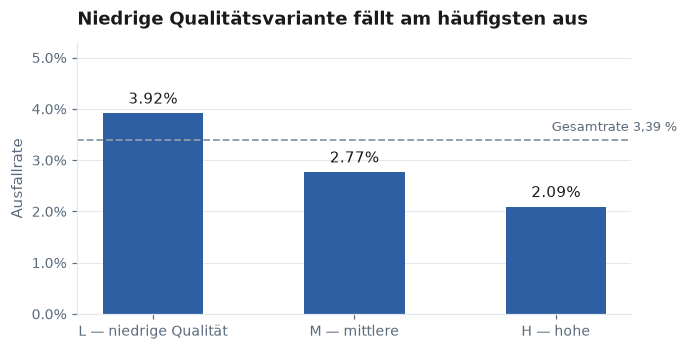

In [9]:
fig, ax = plt.subplots(figsize=(6.5, 3.2))

bezeichnung = {"L": "L — niedrige Qualität", "M": "M — mittlere", "H": "H — hohe"}
positionen = np.arange(len(je_typ))

ax.bar(positionen, je_typ["ausfallrate"], width=0.5, color=FARBEN["kein_ausfall"])

for pos, rate in zip(positionen, je_typ["ausfallrate"]):
    ax.text(pos, rate + 0.0012, f"{rate:.2%}", ha="center", va="bottom",
            fontsize=9.5, color=FARBEN["text"])

ax.axhline(positiv_anteil, color=FARBEN["neutral"], linewidth=1.2, linestyle="--")
ax.text(len(je_typ) - 0.4, positiv_anteil + 0.0012, "Gesamtrate 3,39 %",
        ha="right", va="bottom", fontsize=8.5, color=FARBEN["text_sekundaer"])

ax.set_xticks(positionen, [bezeichnung[t] for t in je_typ.index])
ax.set_ylabel("Ausfallrate")
ax.set_ylim(0, je_typ["ausfallrate"].max() * 1.35)
ax.yaxis.set_major_formatter(lambda x, _: f"{x:.1%}")
ax.set_title("Niedrige Qualitätsvariante fällt am häufigsten aus", loc="left")
nur_y_gitter(ax)

speichere(fig, "03_ausfallrate_je_typ")
plt.show()

Die Ausfallrate steigt von der hohen zur niedrigen Qualitätsvariante spürbar an,
weshalb `type` als Merkmal ins Modell gehört — allerdings one-hot-kodiert, da die
drei Stufen zwar geordnet sind, ihr Abstand aber nicht bezifferbar ist.

## 6 Korrelationen

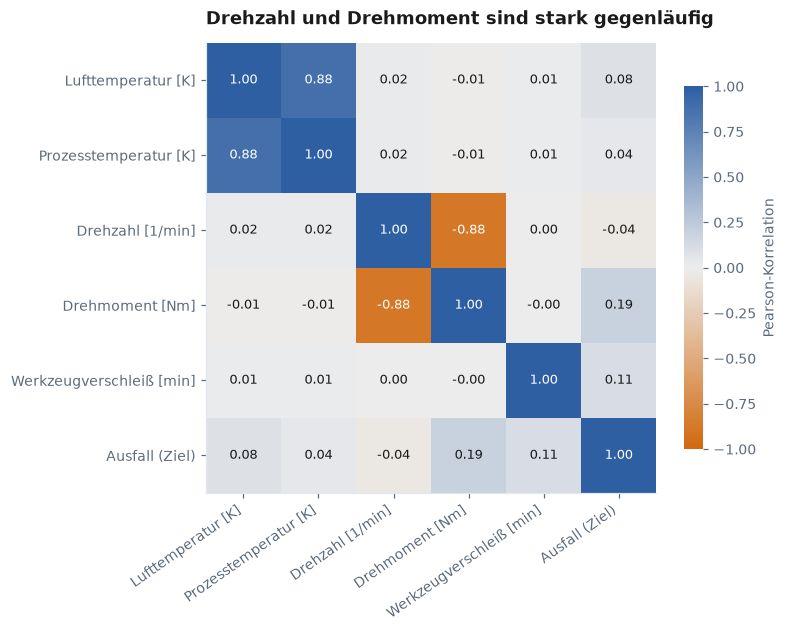

In [10]:
spalten = merkmale_numerisch + [TARGET_COLUMN]
korrelation = df[spalten].corr()

etikett = {**beschriftung, TARGET_COLUMN: "Ausfall (Ziel)"}
namen = [etikett[s] for s in spalten]

fig, ax = plt.subplots(figsize=(7.2, 6))
bild = ax.imshow(korrelation, cmap=CMAP_KORRELATION, vmin=-1, vmax=1)

ax.set_xticks(range(len(namen)), namen, rotation=35, ha="right")
ax.set_yticks(range(len(namen)), namen)
ax.grid(False)

for i in range(len(namen)):
    for j in range(len(namen)):
        wert = korrelation.iloc[i, j]
        ax.text(j, i, f"{wert:.2f}", ha="center", va="center", fontsize=8.5,
                color="white" if abs(wert) > 0.55 else FARBEN["text"])

leiste = fig.colorbar(bild, ax=ax, shrink=0.75)
leiste.outline.set_visible(False)
leiste.set_label("Pearson-Korrelation", fontsize=9)

ax.set_title("Drehzahl und Drehmoment sind stark gegenläufig", loc="left")
fig.tight_layout()

speichere(fig, "04_korrelationen")
plt.show()

Drehzahl und Drehmoment korrelieren stark negativ (die mechanische Leistung ist
im Datensatz näherungsweise konstant), und die beiden Temperaturen hängen eng
zusammen — für baumbasierte Modelle ist das unkritisch, für die logistische
Regression in Etappe 7 ist es beim Interpretieren der Koeffizienten zu beachten.

## 7 Data Leakage

Die Spalten `TWF`, `HDF`, `PWF`, `OSF` und `RNF` beschreiben die **Ursache** eines
Ausfalls. Sie entstehen gemeinsam mit dem Ausfall und sind zum Vorhersagezeitpunkt
nicht bekannt.

In [11]:
ursachen = pd.DataFrame({
    "Fälle": [int(df[c].sum()) for c in LEAKAGE_COLUMNS],
    "Korrelation mit Ziel": [float(df[c].corr(df[TARGET_COLUMN])) for c in LEAKAGE_COLUMNS],
}, index=[c.upper() for c in LEAKAGE_COLUMNS])

# Wie viele Ausfälle werden allein durch die Ursachenspalten erklärt?
mit_ursache = (df[list(LEAKAGE_COLUMNS)].sum(axis=1) > 0)
print(f"Ausfälle gesamt                   : {int(df[TARGET_COLUMN].sum())}")
print(f"davon mit gesetzter Ursachenspalte : {int((mit_ursache & (df[TARGET_COLUMN] == 1)).sum())}")
ursachen.round(3)

Ausfälle gesamt                   : 339
davon mit gesetzter Ursachenspalte : 330


,Fälle,Korrelation mit Ziel
TWF,46,0.363
HDF,115,0.576
PWF,95,0.523
OSF,98,0.531
RNF,19,0.005


### Warum ergeben die Fallzahlen mehr als die Ausfälle?

Die fünf Ursachenspalten summieren sich auf 373 gesetzte Markierungen, es gibt
aber nur 339 Ausfälle. 
Dafür gibt es zwei Gründe, und beide sagen etwas über die Qualität der Daten aus.

In [12]:
anzahl_ursachen = df[list(LEAKAGE_COLUMNS)].sum(axis=1)

print("Summe aller Ursachen-Markierungen   :", int(df[list(LEAKAGE_COLUMNS)].sum().sum()))
print("Zeilen mit mindestens einer Ursache :", int((anzahl_ursachen > 0).sum()))
print("Ausfälle (machine_failure == 1)     :", int(df[TARGET_COLUMN].sum()))

print("\nUrsachen je betroffener Zeile:")
print(anzahl_ursachen[anzahl_ursachen > 0].value_counts().sort_index().to_string())

pd.crosstab(
    df[TARGET_COLUMN] == 1,
    anzahl_ursachen > 0,
    rownames=["Ausfall"],
    colnames=["Ursache gesetzt"],
)

Summe aller Ursachen-Markierungen   : 373
Zeilen mit mindestens einer Ursache : 348
Ausfälle (machine_failure == 1)     : 339

Ursachen je betroffener Zeile:
1    324
2     23
3      1


Ursache gesetzt,False,True
Ausfall,,
False,9643,18
True,9,330


**1.** Eine Maschine kann aus mehreren Gründen
gleichzeitig ausfallen:
23 Zeilen tragen zwei gesetzte Ursachen 
1 drei Ursachen. 
Die 373 Markierungen verteilen sich deshalb auf nur 348 Zeilen; 
die Spaltensumme zählt dieselbe Zeile mehrfach.

**2.** Zielgröße und Ursachen passen nicht exakt zusammen. 
Die Kreuztabelle zeigt 18 Zeilen mit gesetzter Ursache, aber ohne Ausfall 
und
9 Ausfälle, wo keine einzige Ursache markiert ist.

In [13]:
je_ursache = pd.DataFrame(
    {
        "gesetzt": [int(df[c].sum()) for c in LEAKAGE_COLUMNS],
        "davon Ausfall": [
            int(((df[c] == 1) & (df[TARGET_COLUMN] == 1)).sum()) for c in LEAKAGE_COLUMNS
        ],
    },
    index=[c.upper() for c in LEAKAGE_COLUMNS],
)
je_ursache["Trefferquote %"] = (
    je_ursache["davon Ausfall"] / je_ursache["gesetzt"] * 100
).round(1)
je_ursache

,gesetzt,davon Ausfall,Trefferquote %
TWF,46,46,100.0
HDF,115,115,100.0
PWF,95,95,100.0
OSF,98,98,100.0
RNF,19,1,5.3


`TWF`, `HDF`, `PWF` und `OSF` stimmen zu **hundert Prozent** mit der Zielgröße
überein: jede gesetzte Markierung ist auch ein Ausfall. `RNF` ist die Ausnahme —
von 19 Markierungen führt genau eine zum Ausfall. Das passt zur Bedeutung der
Spalte: „random failure" bezeichnet ein zufälliges Ereignis, das bei der
Erzeugung des Datensatzes zwar vermerkt, aber nicht in die Zielgröße übernommen
wurde. Genau deshalb liegt ihre Korrelation bei 0,005, während die anderen vier
zwischen 0,36 und 0,58 liegen.

Für die 9 Ausfälle ohne jede Ursachenangabe gibt es dagegen keine Erklärung im
Datensatz — hier sind Label und Ursachen schlicht inkonsistent.

**Was daraus folgt:** Die Ursachenspalten sind nicht nur Data Leakage, sie sind
auch nicht zuverlässig mit dem Label verknüpft. Die Ursachenspalten werden entfernt.

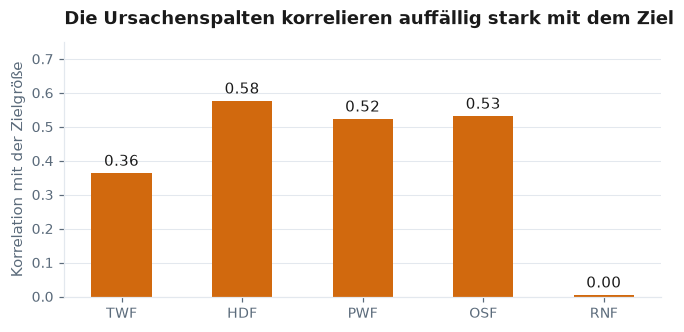

In [14]:
fig, ax = plt.subplots(figsize=(7, 3))

positionen = np.arange(len(ursachen))
werte = ursachen["Korrelation mit Ziel"].to_numpy()

ax.bar(positionen, werte, width=0.5, color=FARBEN["ausfall"])
for pos, wert in zip(positionen, werte):
    ax.text(pos, wert + 0.012, f"{wert:.2f}", ha="center", va="bottom",
            fontsize=9.5, color=FARBEN["text"])

ax.set_xticks(positionen, ursachen.index)
ax.set_ylabel("Korrelation mit der Zielgröße")
ax.set_ylim(0, max(werte) * 1.3)
ax.set_title("Die Ursachenspalten korrelieren auffällig stark mit dem Ziel", loc="left")
nur_y_gitter(ax)

speichere(fig, "05_leakage_ursachenspalten")
plt.show()

Die Ursachenspalten erklären fast jeden Ausfall und korrelieren entsprechend stark
mit der Zielgröße.

## 8 Drehmoment gegen Drehzahl

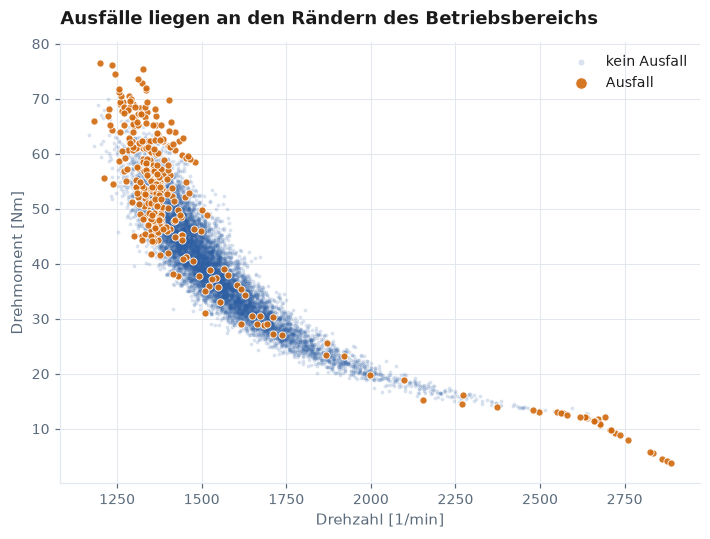

In [15]:
fig, ax = plt.subplots(figsize=(7.5, 5.2))

normal = df[df[TARGET_COLUMN] == 0]
ausfall = df[df[TARGET_COLUMN] == 1]

ax.scatter(normal["rotational_speed_rpm"], normal["torque_nm"],
           s=6, color=FARBEN["kein_ausfall"], alpha=0.18, linewidths=0,
           label=KLASSEN[0])
ax.scatter(ausfall["rotational_speed_rpm"], ausfall["torque_nm"],
           s=22, color=FARBEN["ausfall"], alpha=0.9,
           edgecolors="white", linewidths=0.6, label=KLASSEN[1])

ax.set_xlabel("Drehzahl [1/min]")
ax.set_ylabel("Drehmoment [Nm]")
ax.set_title("Ausfälle liegen an den Rändern des Betriebsbereichs", loc="left")
ax.legend(loc="upper right", markerscale=1.6)

speichere(fig, "06_betriebspunkt")
plt.show()

Die Ausfälle sammeln sich an zwei gegenüberliegenden Rändern — hohe Last bei
niedriger Drehzahl und niedrige Last bei hoher Drehzahl —, also in Bereichen
auffälliger mechanischer Leistung; genau diese Nichtlinearität wird ein lineares
Modell nicht abbilden können.

## 9 Gruppenstruktur


In [16]:
print("Zeilen gesamt          :", len(df))
print("eindeutige product_id  :", df["product_id"].nunique())
print("eindeutige udi         :", df["udi"].nunique())
print("\nJede Zeile ein eigenes Werkstück:", bool(df["product_id"].is_unique))

Zeilen gesamt          : 10000
eindeutige product_id  : 10000
eindeutige udi         : 10000

Jede Zeile ein eigenes Werkstück: True


Jede Zeile trägt eine eigene `product_id`, es gibt also keine Gruppenstruktur und
keinen Zeitstempel — die Aufteilung darf zeilenweise erfolgen,
geschichtet nach der Zielklasse (`stratify`), und braucht weder `GroupShuffleSplit`
noch einen zeitlichen Schnitt.

## 10 Abgeleitete Größen

Zwei Größen drängen sich auf:

* **Temperaturdifferenz** `process_temperature_k − air_temperature_k` — wie gut die
  Wärme abgeführt wird.
* **Mechanische Leistung** `P = M · 2πn / 60` — die Größe, die Drehmoment und
  Drehzahl zusammenfasst.

Hier wird geprüft, ob sie überhaupt trennen.

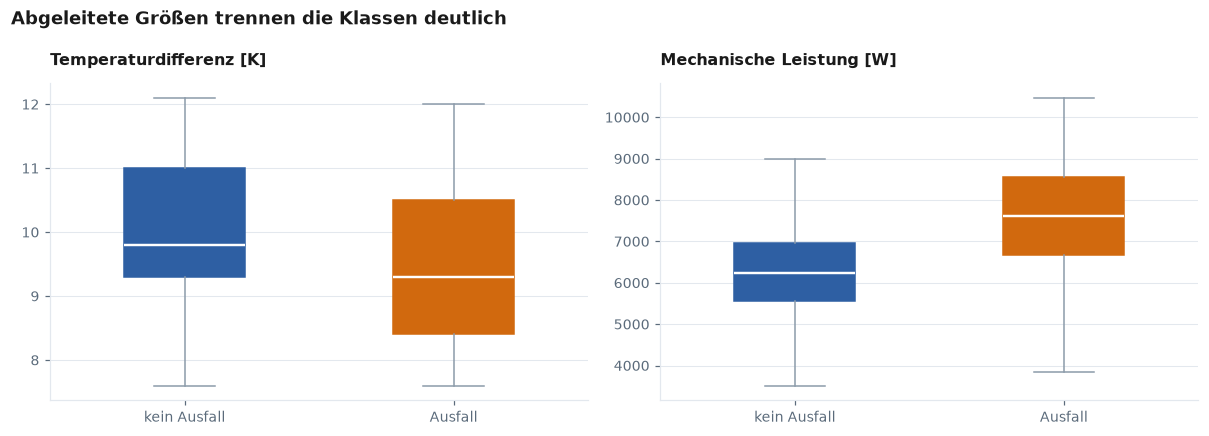

In [17]:
vorschau = pd.DataFrame({
    "temp_difference_k": df["process_temperature_k"] - df["air_temperature_k"],
    "power_w": df["torque_nm"] * df["rotational_speed_rpm"] * 2 * np.pi / 60,
    TARGET_COLUMN: df[TARGET_COLUMN],
})

fig, achsen = plt.subplots(1, 2, figsize=(11, 4))

for ax, spalte, titel in zip(
    achsen,
    ["temp_difference_k", "power_w"],
    ["Temperaturdifferenz [K]", "Mechanische Leistung [W]"],
):
    daten = [vorschau.loc[vorschau[TARGET_COLUMN] == k, spalte] for k in (0, 1)]
    kasten = ax.boxplot(daten, patch_artist=True, widths=0.45, showfliers=False,
                        medianprops={"color": "white", "linewidth": 1.6})
    for koerper, farbe in zip(kasten["boxes"],
                              [FARBEN["kein_ausfall"], FARBEN["ausfall"]]):
        koerper.set_facecolor(farbe)
        koerper.set_edgecolor(farbe)
    for teil in ["whiskers", "caps"]:
        for linie in kasten[teil]:
            linie.set_color(FARBEN["neutral"])
    ax.set_xticks([1, 2], [KLASSEN[0], KLASSEN[1]])
    ax.set_title(titel, loc="left", fontsize=10.5)
    nur_y_gitter(ax)

fig.suptitle("Abgeleitete Größen trennen die Klassen deutlich",
             x=0.005, ha="left", fontsize=12, fontweight="bold")
fig.tight_layout()

speichere(fig, "07_abgeleitete_groessen")
plt.show()

Beide abgeleiteten Größen trennen die Klassen deutlich besser als die
Einzelmerkmale — die Ausfälle liegen bei geringerer Temperaturdifferenz und bei
auffälliger Leistung, was den Aufwand der Merkmalskonstruktion
rechtfertigt, bevor überhaupt an Hyperparameter gedacht wird.

## Summary

| Befund | Folge |
|---|---|
| 3,39 % positive Fälle | Accuracy scheidet aus; PR-AUC und erwartete Kosten als Metrik |
| Keine fehlenden Werte, alle Werte plausibel | Keine Bereinigung nötig |
| Ursachenspalten erklären fast jeden Ausfall | `TWF, HDF, PWF, OSF, RNF` vor der Aufteilung entfernen |
| `TWF/HDF/PWF/OSF` treffen zu 100 %, `RNF` nur zu 5 %; 9 Ausfälle ohne jede Ursache | Label und Ursachen sind inkonsistent |
| Jede Zeile ein eigenes Werkstück, kein Zeitstempel | Zeilenweise, geschichtete Aufteilung zulässig |
| Ausfälle an den Rändern des Betriebsbereichs | Lineares Modell wird deutlich schlechter sein als ein Baumverfahren |
| Temperaturdifferenz und Leistung trennen gut |
| Ausfallrate steigt von H über M nach L | `type` one-hot-kodiert als Merkmal |
| Drehzahl und Drehmoment stark gegenläufig | Bei der logistischen Regression beim Deuten der Koeffizienten beachten |

Alle Abbildungen liegen unter `reports/figures/`.